In [7]:
from datasets import load_dataset

# English only
en = load_dataset("allenai/c4", "en", streaming=True)

### For some reason for the en dataset, the full sample is just from 2019.

## Exploratory Analysis

In [8]:
# Peek at the first record to see available fields
sample = next(iter(en["train"]))
print("Fields:", list(sample.keys()))
print()
for k, v in sample.items():
    preview = str(v)[:200] + "..." if len(str(v)) > 200 else str(v)
    print(f"  {k}: {preview}")

Fields: ['text', 'timestamp', 'url']

  text: Beginners BBQ Class Taking Place in Missoula!
Do you want to get better at making delicious BBQ? You will have the opportunity, put this on your calendar now. Thursday, September 22nd join World Class...
  timestamp: 2019-04-25 12:57:54
  url: https://klyq.com/beginners-bbq-class-taking-place-in-missoula/


In [ ]:
import random
import pandas as pd
import matplotlib.pyplot as plt

# .shard() does not exist on IterableDataset. Use shuffle+take instead.
TOTAL_SAMPLE = 5_000
BUFFER_SIZE  = 10_000
SEED         = 42

shuffled_ds = en["train"].shuffle(buffer_size=BUFFER_SIZE, seed=SEED)

timestamps = []
for record in shuffled_ds.take(TOTAL_SAMPLE):
    ts = record.get("timestamp")
    if ts:
        timestamps.append(ts)

print(f"Sampled {len(timestamps)} records")

# Parse timestamps
dates = pd.to_datetime(timestamps, utc=True)
s = pd.Series(dates)
by_year = s.dt.year.value_counts().sort_index()
by_ym   = s.dt.to_period("M").value_counts().sort_index()

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

by_year.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title(f"Records by Year  (n={len(timestamps):,}, shuffle-sampled)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

by_ym_ts = by_ym.copy()
by_ym_ts.index = by_ym_ts.index.to_timestamp()
by_ym_ts.plot(kind="bar", ax=axes[1], color="darkorange", edgecolor="none", width=1.0)
axes[1].set_title(f"Records by Year-Month  (n={len(timestamps):,}, shuffle-sampled)")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Count")
n_ticks = len(by_ym_ts)
step = max(1, n_ticks // 12)
axes[1].set_xticks(range(0, n_ticks, step))
axes[1].set_xticklabels(
    [f"{by_ym_ts.index[i].year}-{str(by_ym_ts.index[i].month).zfill(2)}"
     for i in range(0, n_ticks, step)],
    rotation=45, ha="right"
)

plt.tight_layout()
plt.show()

In [13]:
# Parse timestamps and compute date range + distribution stats
dates = pd.to_datetime(timestamps, utc=True)
s = pd.Series(dates)

print("=== Date Range ===")
print(f"  Earliest : {s.min()}")
print(f"  Latest   : {s.max()}")
print(f"  Span     : {s.max() - s.min()}")
print()
print("=== Distribution by Year ===")
by_year = s.dt.year.value_counts().sort_index()
for year, count in by_year.items():
    bar = "█" * (count * 40 // by_year.max())
    print(f"  {year}  {count:>6}  {bar}")
print()
print("=== Distribution by Month (all years combined) ===")
by_month = s.dt.month.value_counts().sort_index()
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
for month, count in by_month.items():
    bar = "█" * (count * 40 // by_month.max())
    print(f"  {month_names[month-1]}  {count:>6}  {bar}")

=== Date Range ===
  Earliest : 2019-04-18 10:15:31+00:00
  Latest   : 2019-04-26 17:05:59+00:00
  Span     : 8 days 06:50:28

=== Distribution by Year ===
  2019    5000  ████████████████████████████████████████

=== Distribution by Month (all years combined) ===
  Apr    5000  ████████████████████████████████████████


C:\Users\Dexter\AppData\Local\Temp\ipykernel_26376\511305627.py:14: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  by_ym = s.dt.to_period("M").value_counts().sort_index()


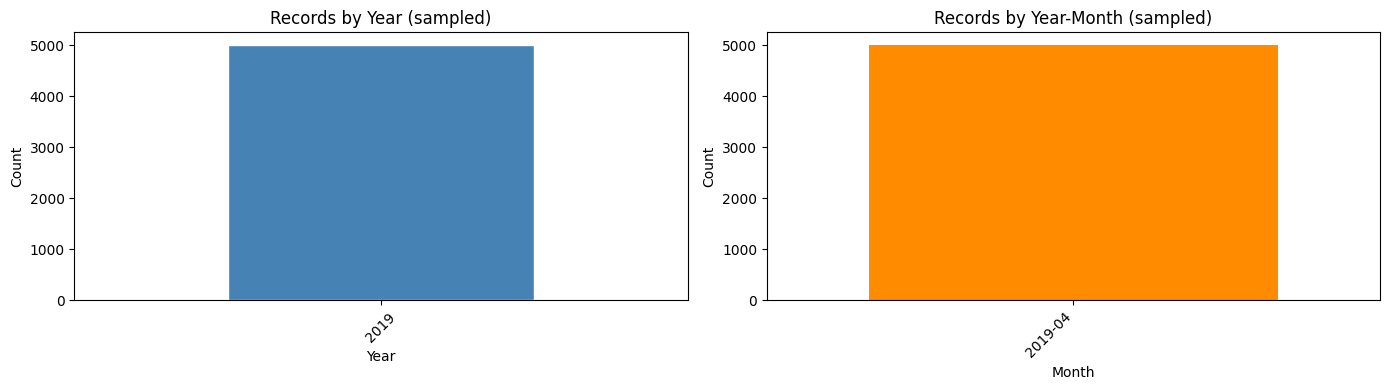

In [11]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Records per year
by_year.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Records by Year (sampled)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

# Records per year-month
by_ym = s.dt.to_period("M").value_counts().sort_index()
by_ym.index = by_ym.index.to_timestamp()
by_ym.plot(kind="bar", ax=axes[1], color="darkorange", edgecolor="none", width=1.0)
axes[1].set_title("Records by Year-Month (sampled)")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Count")
# Show only every 6th tick label to avoid crowding
n_ticks = len(by_ym)
axes[1].set_xticks(range(0, n_ticks, max(1, n_ticks // 12)))
axes[1].set_xticklabels(
    [str(by_ym.index[i].year) + "-" + str(by_ym.index[i].month).zfill(2)
     for i in range(0, n_ticks, max(1, n_ticks // 12))],
    rotation=45, ha="right"
)

plt.tight_layout()
plt.show()